## Fake News Detection Using Machine Learning

## Import Libraries

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score

##Load Dataset

In [14]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [15]:
import os

os.listdir("dataset")

['News _dataset']

In [16]:
import os

os.listdir("dataset/News _dataset")

['True.csv', 'Fake.csv']

In [17]:
os.listdir("dataset/News _dataset")

['True.csv', 'Fake.csv']

In [18]:
fake = pd.read_csv("dataset/News _dataset/Fake.csv")
true = pd.read_csv("dataset/News _dataset/True.csv")

In [19]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [20]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [21]:
fake.shape

(23481, 4)

In [22]:
true.shape

(21417, 4)

## Add Labels

In [23]:
fake["label"] = 0
true["label"] = 1

## Merge Dataset

In [24]:
data = pd.concat([fake, true], axis=0)

data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


## Shuffle Dataset

In [25]:
data = data.sample(frac=1, random_state=42)

data.head()

,title,text,subject,date,label
22216,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
4436,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
1526,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
1377,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
8995,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [26]:
data.shape

(44898, 5)

## Feature Selection

In [27]:
data = data.drop(["title", "subject", "date"], axis=1)

data.head()

,text,label
22216,"21st Century Wire says Ben Stein, reputable pr...",0
4436,WASHINGTON (Reuters) - U.S. President Donald T...,1
1526,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1
1377,"On Monday, Donald Trump once again embarrassed...",0
8995,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",1


In [28]:
X = data["text"]
y = data["label"]

## Train-Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

## TF-IDF Vectorization

In [30]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [31]:
model = PassiveAggressiveClassifier(max_iter=50)

model.fit(X_train, y_train)

PassiveAggressiveClassifier(max_iter=50)

##Prediction

In [32]:
y_pred = model.predict(X_test)

##Accuracy Score

In [33]:
score = accuracy_score(y_test, y_pred)

print("Accuracy:", score)

Accuracy: 0.9928730512249443


In [34]:
print("Accuracy:", score * 100, "%")

Accuracy: 99.28730512249443 %


In [35]:
news = input("Enter News: ")

news_vector = vectorizer.transform([news])

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("True News")

Enter News: The Prime Minister  announced a new education policy today.
Fake News


##Confusion Matrix


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5811   52]
 [  28 5334]]


## Classification Report

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5863
           1       0.99      0.99      0.99      5362

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



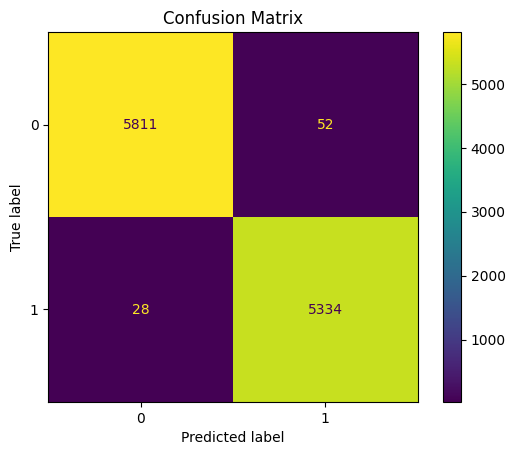

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5863
           1       0.99      0.99      0.99      5362

    accuracy                           0.99     11225
   macro avg       0.99      0.99      0.99     11225
weighted avg       0.99      0.99      0.99     11225



In [40]:
import pickle

pickle.dump(model, open("fake_news_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [41]:
loaded_model = pickle.load(open("fake_news_model.pkl", "rb"))
loaded_vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

print("Model Loaded Successfully")

Model Loaded Successfully


In [42]:
news = input("Enter News: ")

news_vector = loaded_vectorizer.transform([news])

prediction = loaded_model.predict(news_vector)

if prediction[0] == 0:
    print("Fake News")
else:
    print("True News")

Enter News: NASA  successfully launched a new satellite into space.
Fake News


##Sample Prediction

In [44]:
sample_news = "NASA successfully launched a new satellite into space."

sample_vector = vectorizer.transform([sample_news])

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Prediction: Fake News")
else:
    print("Prediction: True News")

Prediction: Fake News


# References

1. Scikit-learn Documentation
2. Pandas Documentation
3. NumPy Documentation
4. Google Colab
5. Kaggle Fake and Real News Dataset

## Dataset Information

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 22216 to 15795
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


## Check Missing Values

In [46]:
data.isnull().sum()

,0
text,0
label,0


## Label Distribution



In [47]:
data["label"].value_counts()

,count
label,
0,23481
1,21417


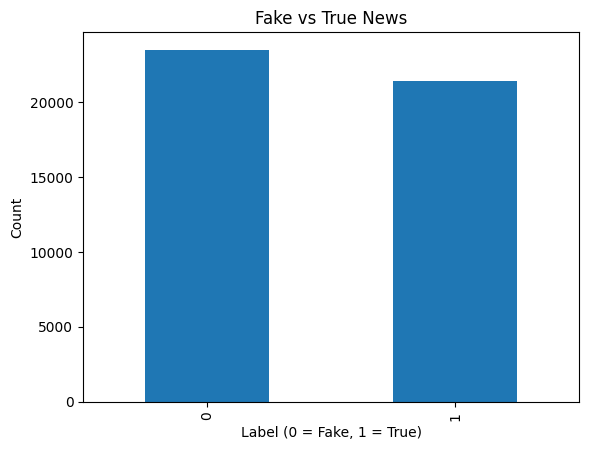

In [48]:
import matplotlib.pyplot as plt

data["label"].value_counts().plot(kind="bar")
plt.title("Fake vs True News")
plt.xlabel("Label (0 = Fake, 1 = True)")
plt.ylabel("Count")
plt.show()

## Dataset Description

This project uses the Fake and True News dataset. The dataset contains news articles with the following columns:

- Title
- Text
- Subject
- Date

After preprocessing, only the text column is used for training the machine learning model.

## Machine Learning Model

Algorithm: Passive Aggressive Classifier

Feature Extraction: TF-IDF Vectorizer

Accuracy: 99.29%

## Random News Prediction

In [49]:
sample = data.sample(1)

print("News:\n")
print(sample["text"].values[0])

news_vector = vectorizer.transform(sample["text"])

prediction = model.predict(news_vector)

if prediction[0] == 0:
    print("\nPrediction: Fake News")
else:
    print("\nPrediction: True News")

print("Actual Label:", sample["label"].values[0])

News:

 The Government-Orchestrated Bankruptcies Of General Motors And Chrysler Led To Tens Of Thousands Of Direct Factory, Supplier And Other Related Job Cuts.   While government influence at decade s end helped Detroit recover financially, the government-orchestrated bankruptcies of General Motors and Chrysler led to tens of thousands of direct factory, supplier and other related job cuts. The primary benefit of the U.S. industry restructuring for employment has been the balance of jobs saved rather than jobs created.  (John Crawley,  Analysis: Obama Seeks Lift From Detroit Auto Jobs,  Reuters, 1/12/12)TARP Inspector General: Tens Of Thousands Of Jobs Were Lost Due To Hasty Factory Closings.  The report by Neil M. Barofsky, the special inspector general for the Troubled Asset Relief Program of the Treasury Department, said both carmakers needed to shut down some underperforming dealerships. But it questioned whether the cuts should have been made so quickly, particularly during a rec

## Project Summary

This project detects whether a news article is Fake or True using Machine Learning.

Algorithm Used:
- Passive Aggressive Classifier

Feature Extraction:
- TF-IDF Vectorizer

Dataset:
- Fake.csv
- True.csv

Total Records:
- 44,898

Accuracy:
- 99.29%

## Conclusion

The Fake News Detection system successfully classifies news articles as Fake or True using the Passive Aggressive Classifier. The model achieved an accuracy of approximately 99.29%, demonstrating that machine learning can effectively identify misleading news articles.

##Future Scope

* Imporve accuracy using deep learning.
* Develop web application.
* Create an android application.
* Support multiple languages.
* Detect fake news from social media platforms.